In [58]:
%load_ext autoreload
%autoreload 2

import numpy as np
import glob as glob
import csv
import matplotlib.pyplot as plt
import os
from pathlib import Path
import re

N_RULES = 60 + 16
N_TIMECONSTS = 36 + 32
INDEX_AND_LOSS = 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [87]:
def read_csv_with_quoted_header(path_pattern):
    # Find first matching file
    files = glob.glob(path_pattern)
    if not files:
        raise FileNotFoundError(f"No files match the pattern: {path_pattern}")
    csv_path = files[0]

    header = []
    with open(csv_path, 'r') as f:
        # Read the first line (header)
        header_line = f.readline().strip()
        curr_word = ''
        in_quote = False
        for c in header_line:
            if in_quote:
                if c == '"':
                    if curr_word != '':
                        header.append(curr_word)
                    curr_word = ''
                    in_quote = False
                else:
                    curr_word += c
            else:
                if c == '"':
                    in_quote = True
                elif c == ' ':
                    if curr_word != '':
                        header.append(curr_word)
                    curr_word = ''
                else:
                    curr_word += c

    # Load data: assume comma-separated numeric values, skipping first line
    data = np.loadtxt(csv_path, delimiter=' ', skiprows=1)

    return header, data

In [88]:
train_path = './sims_out/int_preexist_n40_10_STD_EXPL_0.001_ETA_10.0_L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_FRACI_0.0_SEED_8100_2025-05-20_09:49:55.405355_run_000011/train_data.csv'

In [89]:
header, data = read_csv_with_quoted_header(train_path)

In [100]:
for h in header:
    print(h)

evals
loss
true_loss_0
true_loss_1
true_loss_2
true_loss_3
true_loss_4
true_loss_5
true_loss_6
true_loss_7
true_loss_8
true_loss_9
$HD \rightarrow HD$ 
$HD \rightarrow HD$ $y$
$HD \rightarrow HD$ $x$
$HD \rightarrow HD$ $x \, y$
$HD \rightarrow HD$ $\tilde{y}$
$HD \rightarrow HD$ $x \, \tilde{y}$
$HD \rightarrow HD$ $\tilde{x}$
$HD \rightarrow HD$ $\tilde{x} \, y$
$HD \rightarrow HD$ $\tilde{y} \, y$
$HD \rightarrow HD$ $\tilde{x} \, x$
$HD \rightarrow HD$ $w$
$HD \rightarrow HD$ $w y$
$HD \rightarrow HD$ $w x$
$HD \rightarrow HD$ $w x \, y$
$HD \rightarrow HD$ $w \tilde{y}$
$HD \rightarrow HD$ $w x \, \tilde{y}$
$HD \rightarrow HD$ $w \tilde{x}$
$HD \rightarrow HD$ $w \tilde{x} \, y$
$HD \rightarrow HD$ $w \tilde{y} \, y$
$HD \rightarrow HD$ $w \tilde{x} \, x$
$HD \rightarrow HR$ 
$HD \rightarrow HR$ $y$
$HD \rightarrow HR$ $x$
$HD \rightarrow HR$ $x \, y$
$HD \rightarrow HR$ $\tilde{y}$
$HD \rightarrow HR$ $x \, \tilde{y}$
$HD \rightarrow HR$ $\tilde{x}$
$HD \rightarrow HR$ $\tilde{x

In [96]:
print(len(header))
print(data.shape)

89
(150, 222)


In [91]:
synaptic_contrib_data = data[:, INDEX_AND_LOSS + N_RULES + N_TIMECONSTS:]

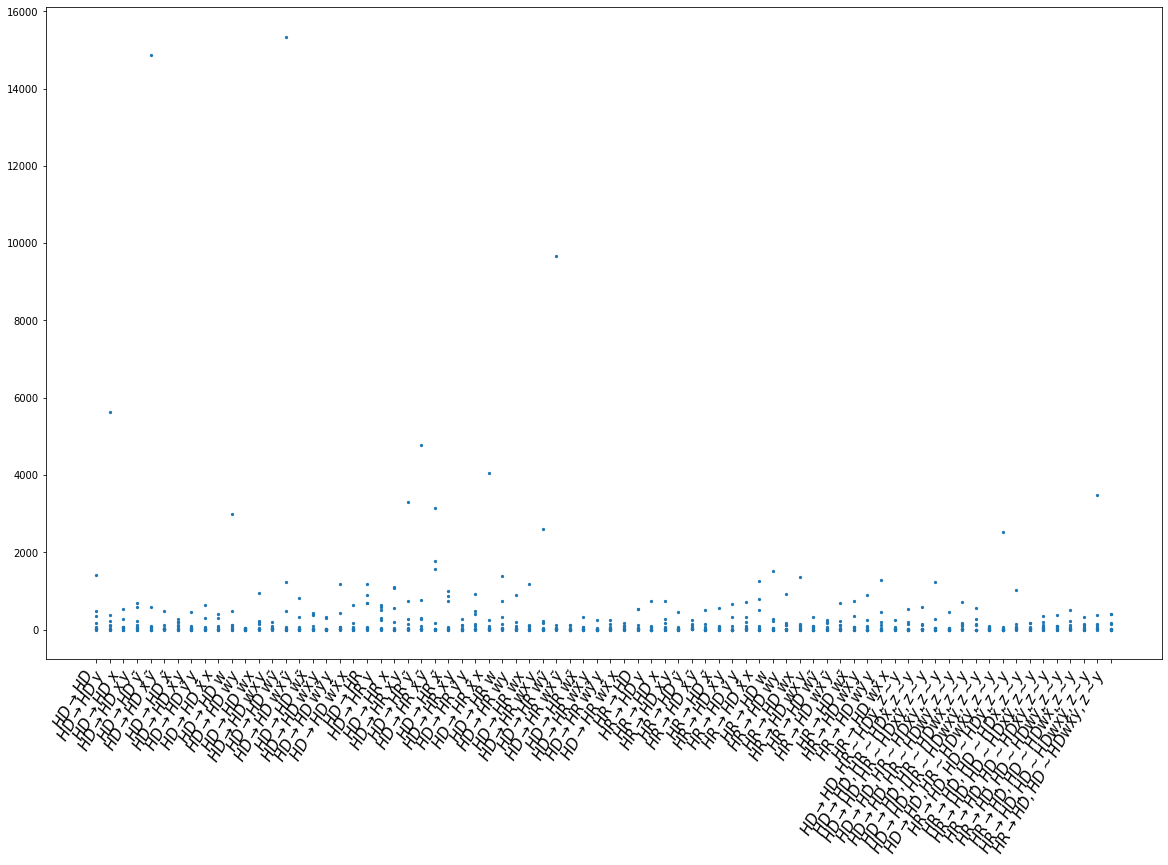

In [109]:
to_include = 10 # synaptic_contrib_data.shape[0]

fig, axs = plt.subplots(1, 1, figsize=(20, 12))
axs.scatter(
    np.stack([np.arange(N_RULES) for i in range(to_include)]),
    synaptic_contrib_data[:to_include, :].T,
    s=5
)
axs.set_xticks(np.arange(N_RULES), header[12:][:-1], rotation=60, ha='right', fontsize=15)
None

0
20
40
60


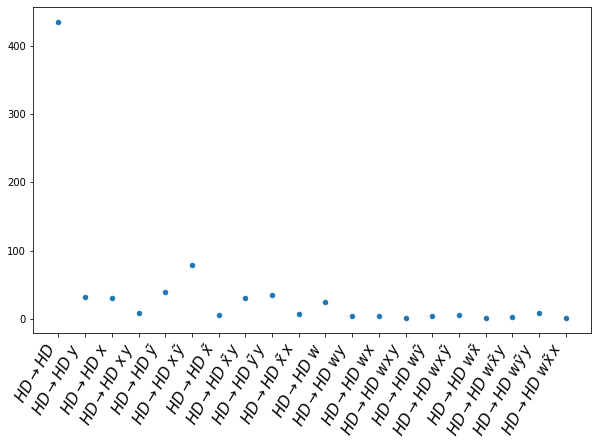

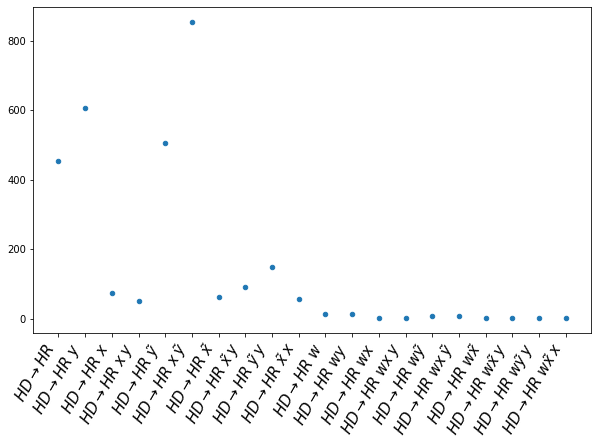

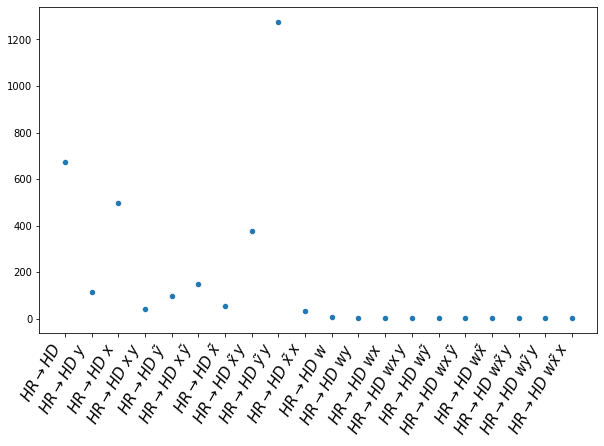

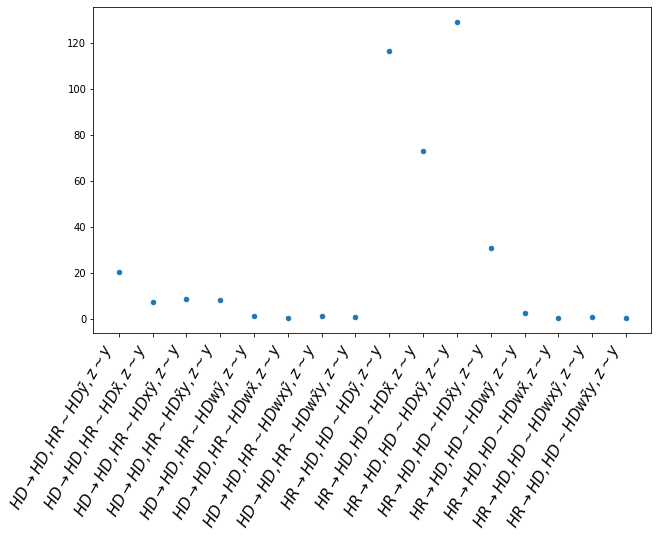

In [118]:
to_include = 30 #synaptic_contrib_data.shape[0]
sections = [20, 20, 20, 16]

for i, s in enumerate(sections):
    start, end = int(np.sum(sections[:i])), int(np.sum(sections[:i+1]))
    print(start)
    fig, axs = plt.subplots(1, 1, figsize=(10, 6))
    axs.scatter(
        np.arange(end-start),
        np.median(synaptic_contrib_data[:to_include, start:end], axis=0),
        s=20
    )
    axs.set_xticks(np.arange(end-start), header[12:][:-1][start:end], rotation=60, ha='right', fontsize=15)
    None